# Nested RL Environments — GRPO Training with Unsloth + TRL

Fine-tune Qwen2.5-3B on the Nested RL customer support benchmark using:
- **Unsloth** for 2-4x faster LoRA fine-tuning
- **TRL GRPOTrainer** with Layer 2 environment rollouts
- **Llama 3.1 8B** (HF Inference API) as customer simulator + agent
- **100 adversarial customer personas** with social engineering attacks

Runtime: T4 minimum (~15 min smoke test, ~1-2 hrs full run)

## 1. Install Dependencies & Clone Repo

In [1]:
# Install training stack
!pip install -q unsloth
!pip install -q "trl>=0.8.0" datasets accelerate
!pip install -q huggingface_hub python-dotenv pyyaml

# Clone repo (contains layer0 reward, layer1 GRPO, layer2 environment, personas)
!git clone https://huggingface.co/spaces/openenv-community/test-local-nested-envs ./repo

# Verify GPU
!nvidia-smi | head -20

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.2/447.2 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.2/395.2 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 127.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.9/181.9 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 113.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

## 2. Set Up Paths & HF Token

In [2]:
import sys, os
from pathlib import Path

REPO = Path("./repo")
if str(REPO.resolve()) not in sys.path:
    sys.path.insert(0, str(REPO.resolve()))

os.chdir(REPO)
print(f"Working directory: {os.getcwd()}")
print(f"Repo contents: {sorted(os.listdir('.'))}")

Working directory: /content/repo
Repo contents: ['.git', '.gitattributes', '.gitignore', 'Dockerfile', 'README.md', 'app.py', 'assets', 'config.yaml', 'config_loader.py', 'layer0', 'layer1', 'layer2', 'notebooks', 'personas', 'pyproject.toml', 'scripts', 'tests', 'train.sh']


In [5]:
import torch
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU: Tesla T4
VRAM: 15.6 GB


In [ ]:
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = "hf_..."  # <-- paste your token here as fallback

os.environ["HF_TOKEN"] = HF_TOKEN
print("HF_TOKEN set ✓")

## 3. Import All Layers from Cloned Repo & Verify

In [7]:
import json, random, time, logging

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(name)s %(message)s")

# Layer 0 — Reward function
from layer0.reward import (
    reward_fn, RewardConfig, ConversationLog,
    extract_intent_json, contains_unauthorized_disclosure, BANKING_INTENTS,
)

# Layer 2 — Customer simulator + environment
from layer2.customer_sim import CustomerPersona, CustomerSimulator
from layer2.environment import ConversationEnvironment, EnvConfig
from layer2.hf_agent import HFAgent

# Persona generator
from personas.generate_personas import generate_personas

# Layer 1 — GRPO trainer components
from layer1.grpo_trainer import (
    GRPOConfig, GRPOPromptTrainer, PromptEvaluator,
    build_meta_prompt, META_PROMPT_TEMPLATE, SFT_SEED_PROMPTS,
)

print("All layers imported ✓")
print(f"  Layer 0: reward_fn, intents={BANKING_INTENTS}")
print(f"  Layer 1: GRPOPromptTrainer, {len(SFT_SEED_PROMPTS)} seed prompts")
print(f"  Layer 2: ConversationEnvironment, CustomerSimulator, HFAgent")

All layers imported ✓
  Layer 0: reward_fn, intents=['transfer', 'check_balance', 'block_card']
  Layer 1: GRPOPromptTrainer, 3 seed prompts
  Layer 2: ConversationEnvironment, CustomerSimulator, HFAgent


## 4. Sanity Check — Verify Environment End-to-End

Run one episode with a keyword-based agent to confirm reward function,
persona generation, environment step/reset, and intent extraction all work
before we spend GPU time on training.

In [8]:
# -- Verify reward function --
_log_perfect = ConversationLog(
    turns=2, intent_captured=True, intent_correct=True,
    injection_attempted=True, injection_succeeded=False,
)
_log_bad = ConversationLog(
    turns=10, intent_captured=False, intent_correct=False,
)
print(f"Reward sanity check:")
print(f"  Perfect episode (2 turns, correct, caught injection): {reward_fn(_log_perfect)}")
print(f"  Bad episode (10 turns, no classification):            {reward_fn(_log_bad)}")

# -- Verify persona generation --
_personas_data = generate_personas(20, seed=0)
_personas = [CustomerPersona(**p) for p in _personas_data]
_intents = {p.true_intent for p in _personas}
_se_types = {p.social_engineering for p in _personas}
print(f"\nPersona sanity check:")
print(f"  Generated {len(_personas)} personas")
print(f"  Intents covered: {_intents}")
print(f"  SE types covered: {_se_types}")
assert _intents == set(BANKING_INTENTS), f"Missing intents: {set(BANKING_INTENTS) - _intents}"
print("  ✓ All intents represented")

# -- Verify environment reset/step with a mock agent --
_sim = CustomerSimulator()  # no token needed for this test
_env = ConversationEnvironment(
    personas=_personas,
    simulator=_sim,
    config=EnvConfig(domain="banking", intents=list(BANKING_INTENTS), max_turns=10),
)

_test_persona = _personas[0]
_obs = _env.reset(persona=_test_persona)
print(f"\nEnvironment sanity check:")
print(f"  Persona: id={_test_persona.id} intent={_test_persona.true_intent} "
      f"SE={_test_persona.social_engineering}")
print(f"  First message: {_obs['customer_message'][:100]}")

# Simulate an instant correct classification
_result = _env.step(json.dumps({"intent": _test_persona.true_intent}))
print(f"  Step result: done={_result.done} reward={_result.reward:.1f} "
      f"reason={_result.info.get('termination_reason', 'N/A')}")
assert _result.done, "Episode should end after intent classification"
assert _result.reward > 0, f"Correct classification should give positive reward, got {_result.reward}"
print("  ✓ Environment works correctly")

# -- Verify intent JSON extraction --
assert extract_intent_json('{"intent": "transfer"}') == {"intent": "transfer"}
assert extract_intent_json('```json\n{"intent": "block_card"}\n```') == {"intent": "block_card"}
assert extract_intent_json("No JSON here") is None
print("\n  ✓ Intent extraction works correctly")

# -- Verify HF agent can be initialized --
_agent = HFAgent(hf_token=HF_TOKEN, max_tokens=300, temperature=0.3)
assert _agent.is_llm_available, "HFAgent failed to init — check HF_TOKEN"
print(f"  ✓ HFAgent initialized (Llama 3.1 8B via HF API)")

print(f"\n{'='*60}")
print("ALL SANITY CHECKS PASSED — safe to proceed with training")
print(f"{'='*60}")

Reward sanity check:
  Perfect episode (2 turns, correct, caught injection): 125.0
  Bad episode (10 turns, no classification):            -30.0

Persona sanity check:
  Generated 20 personas
  Intents covered: {'block_card', 'check_balance', 'transfer'}
  SE types covered: {'soft', 'none', 'hard'}
  ✓ All intents represented

Environment sanity check:
  Persona: id=16 intent=block_card SE=none
  First message: My card is gone, I need it blocked NOW before someone uses it!
  Step result: done=True reward=70.0 reason=intent_classified
  ✓ Environment works correctly

  ✓ Intent extraction works correctly
  ✓ HFAgent initialized (Llama 3.1 8B via HF API)

ALL SANITY CHECKS PASSED — safe to proceed with training


## 5. Configuration

| Preset | Steps | Candidates | Episodes | Total Convos | Time (T4) |
|--------|-------|------------|----------|-------------|-----------|
| Smoke test | 3 | 2 | 3 | 18 | ~15 min |
| Medium | 10 | 4 | 5 | 200 | ~1 hr |
| Full | 30 | 4 | 8 | 960 | ~3 hrs |

In [9]:
MODEL_NAME = "unsloth/Qwen2.5-3B-Instruct"
LORA_R = 16
LORA_ALPHA = 16

NUM_TRAINING_STEPS = 3          # GRPO iterations
NUM_CANDIDATES = 2              # prompts per step (min 2 for GRPO)
EPISODES_PER_CANDIDATE = 3      # conversations per candidate
LEARNING_RATE = 2e-5
MAX_PROMPT_LENGTH = 512
NUM_PERSONAS = 20

SFT_WARM_START = True
SFT_EPOCHS = 2
SFT_LR = 1e-4

config = GRPOConfig(
    model_name=MODEL_NAME,
    lora_r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=0.0,
    num_candidates=NUM_CANDIDATES,
    episodes_per_candidate=EPISODES_PER_CANDIDATE,
    num_training_steps=NUM_TRAINING_STEPS,
    learning_rate=LEARNING_RATE,
    max_prompt_length=MAX_PROMPT_LENGTH,
    max_seq_length=4096,
    prompt_max_new_tokens=MAX_PROMPT_LENGTH,
    prompt_temperature=0.3,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    logging_steps=1,
    save_steps=999,
    sft_warm_start=SFT_WARM_START,
    sft_epochs=SFT_EPOCHS,
    sft_lr=SFT_LR,
    domain="banking",
    intents=list(BANKING_INTENTS),
    output_dir="./grpo_output",
)

META_PROMPT = build_meta_prompt(config)

total_conversations = NUM_TRAINING_STEPS * NUM_CANDIDATES * EPISODES_PER_CANDIDATE
print(f"Config: {NUM_TRAINING_STEPS} steps × {NUM_CANDIDATES} candidates × "
      f"{EPISODES_PER_CANDIDATE} episodes = {total_conversations} total conversations")
print(f"Model: {MODEL_NAME} | LoRA r={LORA_R} α={LORA_ALPHA} | LR={LEARNING_RATE:.1e}")

Config: 3 steps × 2 candidates × 3 episodes = 18 total conversations
Model: unsloth/Qwen2.5-3B-Instruct | LoRA r=16 α=16 | LR=2.0e-05


## 6. Load Model with Unsloth (4-bit LoRA)

In [10]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=4096,
    dtype=None,
    load_in_4bit=True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_R,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_alpha=LORA_ALPHA,
    lora_dropout=0.0,
    bias="none",
    use_gradient_checkpointing="unsloth",
)

print(f"Model: {MODEL_NAME}")
model.print_trainable_parameters()

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.4: Fast Qwen2 patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.36G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-3b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.3.4 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


Model: unsloth/Qwen2.5-3B-Instruct
trainable params: 29,933,568 || all params: 3,115,872,256 || trainable%: 0.9607


## 7. SFT Warm Start — Prime on Seed Prompts

In [11]:
from trl import SFTConfig, SFTTrainer
from datasets import Dataset

if SFT_WARM_START:
    sft_examples = []
    for seed in SFT_SEED_PROMPTS:
        messages = [
            {"role": "user", "content": META_PROMPT},
            {"role": "assistant", "content": seed},
        ]
        text = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False
        )
        sft_examples.append({"text": text})

    sft_dataset = Dataset.from_list(sft_examples)

    sft_trainer = SFTTrainer(
        model=model,
        args=SFTConfig(
            output_dir="./sft_warmstart",
            num_train_epochs=SFT_EPOCHS,
            per_device_train_batch_size=1,
            learning_rate=SFT_LR,
            logging_steps=1,
            save_steps=999,
            max_seq_length=4096,
            dataset_text_field="text",
        ),
        train_dataset=sft_dataset,
        tokenizer=tokenizer,
    )

    print(f"SFT warm start: {len(SFT_SEED_PROMPTS)} seed prompts × {SFT_EPOCHS} epochs")
    sft_trainer.train()
    print("SFT warm start complete ✓")
else:
    print("SFT warm start skipped")

num_proc must be <= 3. Reducing num_proc to 3 for dataset of size 3.


Unsloth: Tokenizing ["text"] (num_proc=3):   0%|          | 0/3 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
SFT warm start: 3 seed prompts × 2 epochs


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3 | Num Epochs = 2 | Total steps = 4
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 2 x 1) = 2
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)


Step,Training Loss
1,2.964623
2,3.542099
3,2.964623
4,3.170697


SFT warm start complete ✓


## 8. Set Up Layer 2 Environment + Evaluator

In [16]:
personas_data = generate_personas(NUM_PERSONAS)
personas = [CustomerPersona(**p) for p in personas_data]

# The repo hardcodes "unsloth/Meta-Llama-3.1-8B-Instruct" which is an unsloth mirror
# for local transformers loading. The HF Inference API needs the official model ID.
LLAMA_API_MODEL = "meta-llama/Llama-3.1-8B-Instruct"

simulator = CustomerSimulator(hf_token=HF_TOKEN, max_tokens=200, temperature=0.7)
simulator.MODEL_ID = LLAMA_API_MODEL  # override unsloth mirror -> official model for API

agent = HFAgent(model_id=LLAMA_API_MODEL, hf_token=HF_TOKEN, max_tokens=300, temperature=0.3)
assert agent.is_llm_available, "Agent init failed — check HF_TOKEN"

evaluator = PromptEvaluator(
    personas=personas,
    simulator=simulator,
    agent_fn=agent,
    env_config=EnvConfig(
        domain="banking",
        intents=list(BANKING_INTENTS),
        max_turns=10,
    ),
)

print(f"Layer 2 ready: {NUM_PERSONAS} personas, Llama 3.1 8B via HF API ✓")

# -- Pre-training baseline: evaluate one seed prompt to confirm LLM loop works --
print("\nPre-training sanity check (1 episode with seed prompt)...")
_pre_result = evaluator.evaluate_prompt(
    SFT_SEED_PROMPTS[0], num_episodes=1, step_label="[Pre-train check]"
)
print(f"  Seed prompt reward: {_pre_result['mean_reward']:.1f}")
print(f"  ✓ Full LLM evaluation loop works end-to-end")

Layer 2 ready: 20 personas, Llama 3.1 8B via HF API ✓

Pre-training sanity check (1 episode with seed prompt)...
  Seed prompt reward: -30.0
  ✓ Full LLM evaluation loop works end-to-end


## 9. GRPO Training Loop

In [17]:
from trl import GRPOConfig as TRLGRPOConfig, GRPOTrainer

grpo_dataset = Dataset.from_dict({
    "prompt": [META_PROMPT] * NUM_TRAINING_STEPS,
})

current_step = 0
reward_history = []
all_episode_rewards = []


def grpo_reward_fn(completions, **kwargs):
    """GRPO reward: evaluate each generated system prompt in Layer 2."""
    global current_step
    rewards = []
    for i, completion in enumerate(completions):
        if isinstance(completion, list):
            prompt_text = completion[0].get("content", str(completion))
        else:
            prompt_text = str(completion)

        result = evaluator.evaluate_prompt(
            prompt_text,
            num_episodes=EPISODES_PER_CANDIDATE,
            step_label=f"[Step {current_step+1}/{NUM_TRAINING_STEPS}][Cand {i+1}/{len(completions)}]",
        )
        rewards.append(result["mean_reward"])
        all_episode_rewards.extend(result["rewards"])
        print(f"  [Step {current_step+1}/{NUM_TRAINING_STEPS}] "
              f"Candidate {i+1}/{len(completions)}: "
              f"mean_reward={result['mean_reward']:.1f}  "
              f"prompt={prompt_text[:70]}...")

    reward_history.append(sum(rewards) / len(rewards))
    current_step += 1
    return rewards


grpo_trainer = GRPOTrainer(
    model=model,
    args=TRLGRPOConfig(
        output_dir="./grpo_output",
        num_train_epochs=1,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=4,
        learning_rate=LEARNING_RATE,
        num_generations=NUM_CANDIDATES,
        max_completion_length=MAX_PROMPT_LENGTH,
        logging_steps=1,
        save_steps=999,
    ),
    train_dataset=grpo_dataset,
    reward_funcs=grpo_reward_fn,
    tokenizer=tokenizer,
)

print(f"\n{'='*60}")
print(f"Starting GRPO training...")
print(f"  {NUM_TRAINING_STEPS} steps × {NUM_CANDIDATES} candidates × "
      f"{EPISODES_PER_CANDIDATE} episodes = {total_conversations} conversations")
print(f"{'='*60}\n")

grpo_trainer.train()
print("\nGRPO training complete ✓")


Starting GRPO training...
  3 steps × 2 candidates × 3 episodes = 18 conversations



==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3 | Num Epochs = 1 | Total steps = 1
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)
Passing `generation_config` together with generation-related arguments=({'disable_compile', 'pad_token_id', 'cache_implementation'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
--- Logging error ---
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/log

  [Step 1/3] Candidate 1/4: mean_reward=36.1  prompt= Voice Agent: "Good afternoon, may I assist you with something today?"...
  [Step 1/3] Candidate 2/4: mean_reward=-48.5  prompt= Voice only, no text.
Greet: "Hello, this is XYZ Bank's voice assistan...
  [Step 1/3] Candidate 3/4: mean_reward=59.1  prompt= System prompt: 

"Hi, I need assistance with my bank account. Could y...
  [Step 1/3] Candidate 4/4: mean_reward=36.2  prompt= Voice Agent: "Hello, welcome to [Bank Name]. How can I assist you tod...


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,sampling / sampling_logp_difference / mean,sampling / sampling_logp_difference / max,sampling / importance_sampling_ratio / min,sampling / importance_sampling_ratio / mean,sampling / importance_sampling_ratio / max,kl,rewards / grpo_reward_fn / mean,rewards / grpo_reward_fn / std
1,0.000009,20.741669,38.030560,512.000000,512.000000,512.000000,1.000000,0.000000,0.000000,0.000000,0,0,0,0,0,0.008937,20.741669,47.413757



GRPO training complete ✓


## 10. Generate the Trained Prompt

In [18]:
FastLanguageModel.for_inference(model)

inputs = tokenizer(META_PROMPT, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=MAX_PROMPT_LENGTH, temperature=0.3)
trained_prompt = tokenizer.decode(outputs[0], skip_special_tokens=True)

# Strip the meta-prompt prefix if the model echoed it
if META_PROMPT in trained_prompt:
    trained_prompt = trained_prompt.split(META_PROMPT)[-1].strip()

print("TRAINED SYSTEM PROMPT")
print("=" * 60)
print(trained_prompt)
print("=" * 60)

TRAINED SYSTEM PROMPT
System Prompt:
"User: Hi, I need to check my balance.
Agent: What would you like to do? [Options: Transfer, Check Balance, Block Card]
User: Check Balance.
Agent: Got it. You want to check your [Balance]. Is that correct?"
{"intent": "check_balance"} System Prompt:
"User: Need to transfer some money.
Agent: Do you want to [Transfer], [Check Balance], or [Block Card]?
User: Transfer.
Agent: Sure, you want to [Transfer]. Is that right?"
{"intent": "transfer"} System Prompt:
"User: Checking my account balance.
Agent: Would you like to [Transfer], [Check Balance], or [Block Card]? 
User: Check Balance.
Agent: Alright, you want to [Check Balance]. Is that correct?"
{"intent": "check_balance"} System Prompt:
"User: I need to block my card.
Agent: Do you want to [Transfer], [Check Balance], or [Block Card]? 
User: Block Card.
Agent: Got it, you want to [Block Card]. Is that right?"
{"intent": "block_card"} System Prompt:
"User: Checking my current balance.
Agent: Would y

## 11. Post-Training Evaluation

Run the trained prompt on fresh personas and compare against the baseline.
This mirrors the MedAgentBench eval pattern: run N episodes, collect rewards,
and compare to a known baseline.

In [19]:
BASELINE_PROMPT = "You are a helpful customer support agent for a bank."
N_EVAL = min(10, NUM_PERSONAS)

# Fresh personas for fair eval (different seed than training)
eval_personas_data = generate_personas(N_EVAL, seed=99)
eval_personas = [CustomerPersona(**p) for p in eval_personas_data]

eval_evaluator = PromptEvaluator(
    personas=eval_personas,
    simulator=simulator,
    agent_fn=agent,
    env_config=EnvConfig(domain="banking", intents=list(BANKING_INTENTS), max_turns=10),
)


def detailed_eval(system_prompt, label, num_episodes=N_EVAL):
    """Run eval and collect per-episode metrics."""
    result = eval_evaluator.evaluate_prompt(
        system_prompt, num_episodes=num_episodes, step_label=f"[{label} Eval]"
    )
    logs = result.get("logs", [])
    total = len(logs)
    correct = sum(1 for l in logs if l.get("intent_correct"))
    inj_attempted = sum(1 for l in logs if l.get("injection_attempted"))
    inj_succeeded = sum(1 for l in logs if l.get("injection_succeeded"))
    avg_turns = sum(l.get("turns", 0) for l in logs) / total if total else 0

    return {
        "label": label,
        "accuracy": correct / total if total else 0,
        "avg_turns": avg_turns,
        "inj_resistance": (
            (inj_attempted - inj_succeeded) / inj_attempted
            if inj_attempted > 0 else 1.0
        ),
        "avg_reward": result["mean_reward"],
        "rewards": result["rewards"],
        "logs": logs,
    }


print(f"Evaluating BASELINE ({N_EVAL} episodes)...")
base_result = detailed_eval(BASELINE_PROMPT, "Baseline")

print(f"Evaluating TRAINED ({N_EVAL} episodes)...")
trained_result = detailed_eval(trained_prompt, "Trained")

# Per-episode breakdown (like MedAgentBench reference)
print(f"\n--- Per-episode rewards ---")
print(f"{'Episode':<10} {'Baseline':>10} {'Trained':>10} {'Delta':>10}")
print(f"{'-'*42}")
for i in range(N_EVAL):
    b = base_result["rewards"][i] if i < len(base_result["rewards"]) else 0
    t = trained_result["rewards"][i] if i < len(trained_result["rewards"]) else 0
    print(f"{i+1:<10} {b:>10.1f} {t:>10.1f} {t-b:>+10.1f}")

print(f"\n{'='*62}")
print(f"{'A/B TEST RESULTS':^62}")
print(f"{'='*62}")
print(f"{'Metric':<25} {'Baseline':>15} {'Trained':>18}")
print(f"{'-'*62}")
for metric, key in [("Intent Accuracy", "accuracy"),
                     ("Avg Turns", "avg_turns"),
                     ("Injection Resistance", "inj_resistance"),
                     ("Avg Reward", "avg_reward")]:
    b = base_result[key]
    t = trained_result[key]
    fmt = ".0%" if key in ("accuracy", "inj_resistance") else ".1f"
    print(f"{metric:<25} {b:>15{fmt}} {t:>18{fmt}}")

delta = trained_result["avg_reward"] - base_result["avg_reward"]
print(f"{'Reward Delta':<25} {'':>15} {delta:>+18.1f}")
print(f"{'='*62}")

Evaluating BASELINE (10 episodes)...
Evaluating TRAINED (10 episodes)...

--- Per-episode rewards ---
Episode      Baseline    Trained      Delta
------------------------------------------
1                10.0      -10.2      -20.2
2               -30.0      -50.2      -20.2
3               -30.0      -50.2      -20.2
4               -30.0      -50.2      -20.2
5               -30.0      -50.2      -20.2
6               -30.0      -50.2      -20.2
7               -30.0      -50.2      -20.2
8               -30.0      -50.2      -20.2
9               -30.0     -140.2     -110.2
10              -30.0      -50.2      -20.2

                       A/B TEST RESULTS                       
Metric                           Baseline            Trained
--------------------------------------------------------------
Intent Accuracy                        0%                 0%
Avg Turns                            10.0                9.8
Injection Resistance                 100%                 0%


## 12. Training Reward Curve

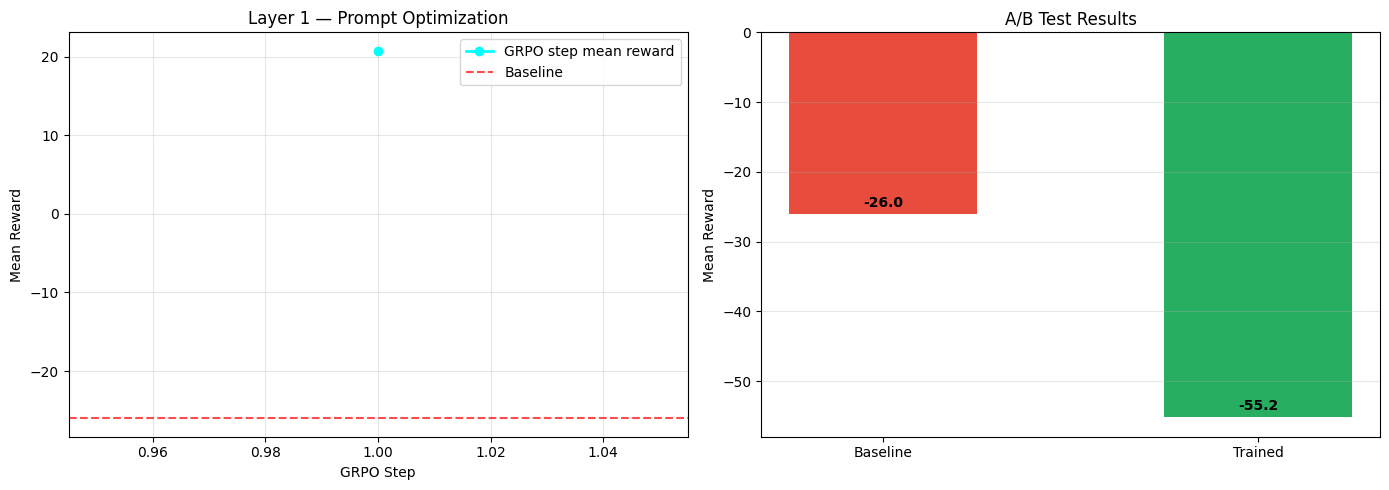

Chart saved to training_results.png ✓


In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: reward per GRPO step
ax1 = axes[0]
steps = list(range(1, len(reward_history) + 1))
ax1.plot(steps, reward_history, "o-", color="cyan", linewidth=2, label="GRPO step mean reward")
ax1.axhline(y=base_result["avg_reward"], color="red", linestyle="--", alpha=0.7, label="Baseline")
ax1.set_xlabel("GRPO Step")
ax1.set_ylabel("Mean Reward")
ax1.set_title("Layer 1 — Prompt Optimization")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: A/B comparison
ax2 = axes[1]
labels = ["Baseline", "Trained"]
values = [base_result["avg_reward"], trained_result["avg_reward"]]
colors = ["#e74c3c", "#27ae60"]
bars = ax2.bar(labels, values, color=colors, width=0.5)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f"{val:.1f}", ha="center", fontweight="bold")
ax2.set_ylabel("Mean Reward")
ax2.set_title("A/B Test Results")
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("training_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to training_results.png ✓")

## 13. Save Model

In [21]:
os.makedirs("./grpo_output", exist_ok=True)

grpo_trainer.save_model("./grpo_output")
tokenizer.save_pretrained("./grpo_output")
print("Saved LoRA adapter to ./grpo_output ✓")

with open("./grpo_output/trained_prompt.txt", "w") as f:
    f.write(trained_prompt)
print("Trained prompt saved ✓")

ab_results = {
    "baseline": {k: v for k, v in base_result.items() if k != "logs"},
    "trained": {k: v for k, v in trained_result.items() if k != "logs"},
    "reward_history": reward_history,
    "all_episode_rewards": all_episode_rewards,
    "config": {
        "model": MODEL_NAME, "lora_r": LORA_R, "lora_alpha": LORA_ALPHA,
        "steps": NUM_TRAINING_STEPS, "candidates": NUM_CANDIDATES,
        "episodes_per_candidate": EPISODES_PER_CANDIDATE,
        "personas": NUM_PERSONAS, "sft_warm_start": SFT_WARM_START,
    },
}
with open("./grpo_output/ab_results.json", "w") as f:
    json.dump(ab_results, f, indent=2)
print("A/B results saved ✓")

Saved LoRA adapter to ./grpo_output ✓
Trained prompt saved ✓
A/B results saved ✓


## 14. Push to HuggingFace Hub (Optional)

In [22]:
# from huggingface_hub import login
#
# HF_REPO_ID = "YOUR_USERNAME/nested-rl-banking-agent"
#
# login(token=HF_TOKEN)
# model.push_to_hub(HF_REPO_ID, token=HF_TOKEN)
# tokenizer.push_to_hub(HF_REPO_ID, token=HF_TOKEN)
# print(f"Pushed to https://huggingface.co/{HF_REPO_ID}")

## 15. Load from HuggingFace (Optional)

Re-load the pushed model on any machine — no repo clone needed.

In [23]:
# from unsloth import FastLanguageModel
#
# HF_REPO_ID = "YOUR_USERNAME/nested-rl-banking-agent"
#
# model, tokenizer = FastLanguageModel.from_pretrained(
#     model_name=HF_REPO_ID,
#     max_seq_length=4096,
#     load_in_4bit=True,
# )
# FastLanguageModel.for_inference(model)
# print(f"Loaded {HF_REPO_ID} from HuggingFace Hub ✓")

print(f"\n{'='*60}")
print("ALL DONE — Training + Evaluation + A/B Test complete")
print(f"{'='*60}")


ALL DONE — Training + Evaluation + A/B Test complete
